TITLE: MACHINE LEARNING

OBJECTIVE:
1.  To understand the fundamentals of machine learning.
2.  To collect, preprocess the dataset and train the model.

THEORY:

Machine Learning:

Machine Learning (ML) is a core branch of Artificial Intelligence (AI) focused on building systems that learn from data, identify complex patterns, and make decisions with minimal human intervention.
Instead of relying on hardcoded instructions, Machine Learning shifts the software paradigm:
Traditional Programming: 
$\text{Inputs} + \text{Rules} \rightarrow \text{Output}$Machine Learning: $\text{Inputs} + \text{Outputs} \rightarrow \text{Discovered Rules}$

Types of Machine Learning

   1.  Supervised Learning: 
    The model is trained using a labeled dataset, meaning every training input is paired with its correct output. It maps inputs to targets to solve Classification tasks (predicting discrete labels like 0 or 1) and Regression tasks (predicting continuous numerical values).

   2.  Unsupervised Learning: The model works with unlabeled data without human guidance. The algorithm scans the dataset's structural properties to discover hidden groupings (Clustering) or simplify data complexity (Dimensionality Reduction).

   3.  Semi-Supervised Learning: A hybrid approach that combines a small amount of labeled data with a large pool of unlabeled data. It uses the labeled points to anchor its understanding and then clusters the remaining data, reducing manual data-labeling expenses.

   4.  Reinforcement Learning: A trial-and-error paradigm where an autonomous agent interacts with an environment. It learns to achieve a goal by receiving cumulative rewards for correct decisions and penalties for mistakes.

The Machine Learning Lifecycle:

 1. Data Collection: Gathering high-quality, relevant raw information from diverse sources such as system logs, databases, web APIs, or physical sensors.

 2. Data Preprocessing: Transforming raw data into a clean format by eliminating duplicate records, handling missing values via statistical imputation (like the median), normalizing feature scales, and capping extreme outliers.

 3. Model Selection: Evaluating and choosing the best mathematical algorithm architecture (such as K-Nearest Neighbors for distance-based patterns) tailored to your specific data structure and project objectives.

 4. Model Training: Feeding the preprocessed data into the chosen algorithm, allowing it to iteratively adjust its internal parameters, minimize performance errors, and lock onto underlying patterns.

 5. Model Evaluation: Testing the finalized model against an isolated, unseen test dataset using structural metrics like Accuracy Scores and Confusion Matrices to guarantee that the system generalizes well to new, real-world data.

#### CODE

In [1]:
!pip install seaborn scikit-learn pandas numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# 1. DATA GENERATION (Adjusted for 4 Input Features + 1 Continuous/Binary Target)
# =====================================================================
# Generate base synthetic dataset (95 points, 4 features, 5th feature is the target)
X, y = make_classification(
    n_samples=95, n_features=4, n_informative=3, 
    n_redundant=1, n_classes=2, random_state=42
)

# Combine into a single dataframe where feature_5 is the actual target class
columns = [f'feature_{i+1}' for i in range(4)]
df = pd.DataFrame(X, columns=columns)
df['feature_5'] = y  # Feature 5 is now the target class to predict!

# Inject 5 duplicate rows from the existing ones to reach 100 samples
duplicate_indices = np.random.choice(df.index, size=5, replace=False)
duplicates = df.loc[duplicate_indices].copy()
df = pd.concat([df, duplicates], ignore_index=True)

# Inject 10 missing values randomly across the first 4 input feature columns
for _ in range(10):
    row = np.random.randint(0, len(df))
    col = np.random.randint(0, 4)
    df.iloc[row, col] = np.nan

# Inject outliers into 5 random rows by adding large values to input features
outlier_indices = np.random.choice(df.index, size=5, replace=False)
for idx in outlier_indices:
    col = np.random.randint(0, 4)
    df.iloc[idx, col] += np.random.choice([-15, 15])


In [4]:
# =====================================================================
# 2. DATA PREPROCESSING
# =====================================================================
# A. Drop duplicate rows
df_preprocessed = df.drop_duplicates().copy()

# B. Impute missing values using column-wise medians
for col in columns:
    median_val = df_preprocessed[col].median()
    df_preprocessed[col] = df_preprocessed[col].fillna(median_val)

# C. Handle outliers using IQR capping
df_capped = df_preprocessed.copy()
for col in columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

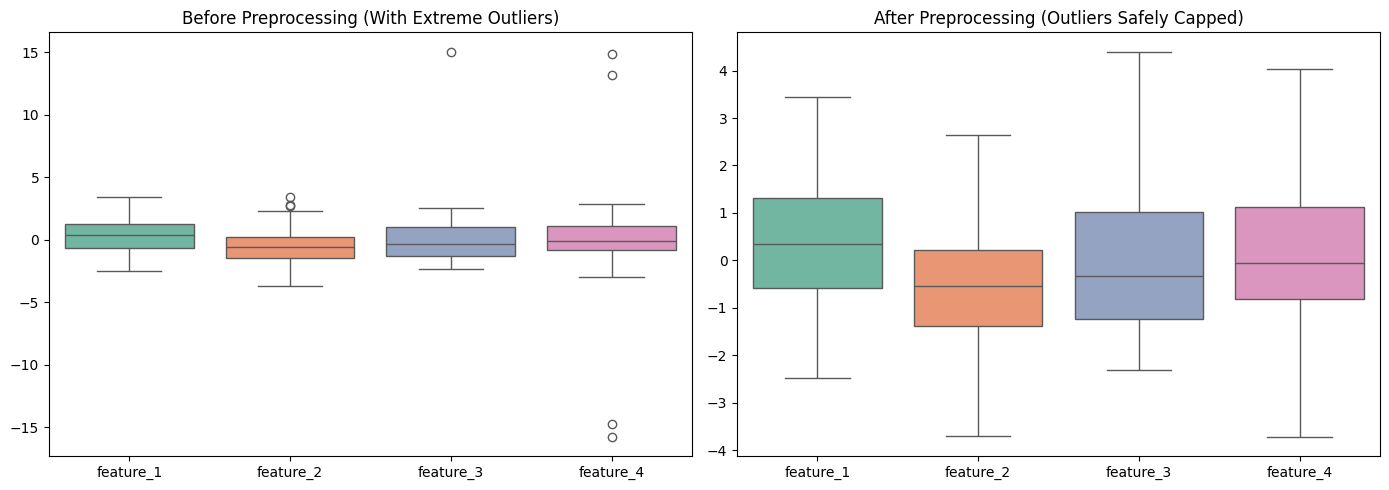

In [4]:
# =====================================================================
# 3. VISUALIZATIONS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[columns], ax=axes[0], palette="Set2")
axes[0].set_title('Before Preprocessing (With Extreme Outliers)')

sns.boxplot(data=df_capped[columns], ax=axes[1], palette="Set2")
axes[1].set_title('After Preprocessing (Outliers Safely Capped)')
plt.tight_layout()
plt.show()

In [5]:

# =====================================================================
# 4. MODEL TRAINING & EVALUATION
# =====================================================================
X_clean = df_capped[columns]      # Features 1 to 4
y_clean = df_capped['feature_5']  # Feature 5 (Target)

# Split data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)

# Scale features (Essential for distance metrics in KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Evaluate standard test matrix
y_pred = knn.predict(X_test_scaled)
print(f"\n--- Baseline Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")



--- Baseline Model Evaluation ---
Accuracy Score: 0.83



  MANUAL PREDICTION SYSTEM WITH TARGET PLOT
Please enter numeric values for the first 4 features to predict feature_5.

------------------------------
🔮 PREDICTED OUTCOME FOR FEATURE 5: 1
Confidence: Class 0 (0.0%) | Class 1 (100.0%)
------------------------------


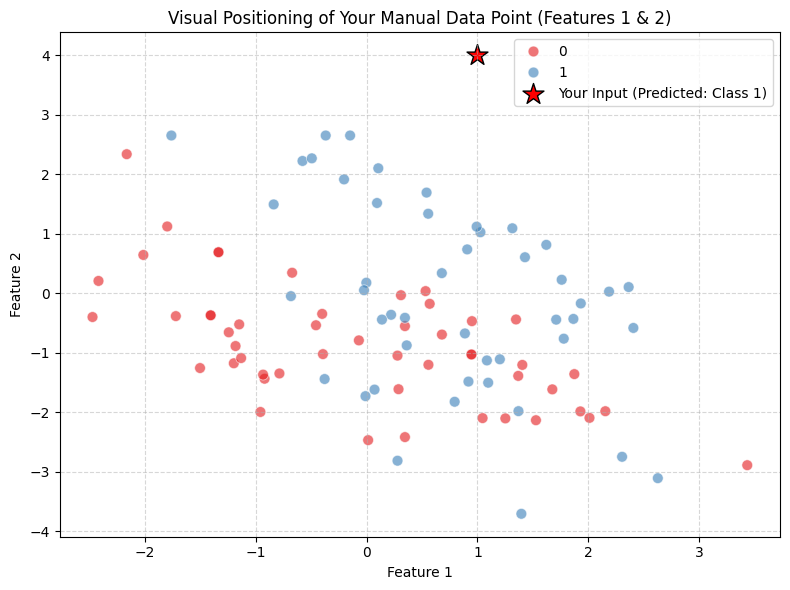

In [7]:

# =====================================================================
# 5. DIAGNOSTIC PREDICTION & TARGET VISUALIZATION
# =====================================================================
print("\n" + "="*50)
print("  MANUAL PREDICTION SYSTEM WITH TARGET PLOT")
print("="*50)
print("Please enter numeric values for the first 4 features to predict feature_5.")

try:
    f1 = float(input("Enter value for Feature 1 (e.g. 0.5): "))
    f2 = float(input("Enter value for Feature 2 (e.g. -1.2): "))
    f3 = float(input("Enter value for Feature 3 (e.g. 2.1): "))
    f4 = float(input("Enter value for Feature 4 (e.g. -0.4): "))
    
    # Clean framework input
    user_input = pd.DataFrame([[f1, f2, f3, f4]], columns=columns)
    user_input_scaled = scaler.transform(user_input)
    
    # Process predictions
    prediction = knn.predict(user_input_scaled)[0]
    probabilities = knn.predict_proba(user_input_scaled)[0]
    
    print("\n" + "-"*30)
    print(f"🔮 PREDICTED OUTCOME FOR FEATURE 5: {prediction}")
    print(f"Confidence: Class 0 ({probabilities[0]*100:.1f}%) | Class 1 ({probabilities[1]*100:.1f}%)")
    print("-"*30)

    # --- NEW: PLOT THE PREDICTED DATA POINT ---
    plt.figure(figsize=(8, 6))
    
    # Plot existing dataset points using Feature 1 and Feature 2
    sns.scatterplot(
        x=df_capped['feature_1'], y=df_capped['feature_2'], 
        hue=df_capped['feature_5'], palette='Set1', alpha=0.6, s=60
    )
    
    # Plot your custom manual input data point as a prominent Red Star
    plt.scatter(
        f1, f2, color='red', marker='*', s=250, edgecolor='black', 
        label=f'Your Input (Predicted: Class {prediction})'
    )
    
    plt.title('Visual Positioning of Your Manual Data Point (Features 1 & 2)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

except ValueError:
    print("\n❌ Error: Please ensure you enter valid numerical numbers.")

#### Discussion
In this lab, we practically applied the machine learning life cycle by building and testing a K-Nearest Neighbors (KNN) classification model. We started by working with a generated dataset that intentionally included common real-world problems like duplicate rows, missing values, and extreme outliers. Seeing the "before and after" boxplots made it really clear why data cleaning is so important before training a model. Once the data was clean and properly scaled, we trained the KNN model and checked its accuracy. The most helpful part of the experiment was setting up the manual prediction system at the end. It allowed us to input custom feature numbers, see the model's confidence in its prediction, and look at a scatter plot to visually track exactly where our new data point landed compared to the rest of the dataset.

#### Conclusion
To conclude, this lab successfully demonstrated the core steps required to build, train, and evaluate a supervised machine learning model. We found that machine learning isn't just about applying an algorithm but also preparing and cleaning the raw data is just as crucial for the model to make accurate predictions. By successfully training the KNN classifier, dealing with messy data, and testing the model with the custom inputs, we gained a much stronger practical understanding of how the different stages of the machine learning life cycle actually work together to create a functional AI system.